# Basic Roadmap

Three things of interest to me are:
1. Class to pull libraries from Enrichr for use downstream
2. Class to enable reweighting via optimal transport.
3. Class to generate a result dataframe, which contains meta-estimates for the z-score, LFCs and standard errors.

then, I want to be able to easily generate forest plots with the contribution and the meta-estimate at the bottom.

# Dataset

In [76]:
df = pd.read_csv("DE_Results.csv").set_index("symbol")

# 1. Pulling from Enrichr

In [77]:
import requests
from functools import reduce

class GeneOntologyLibraries:
    _base_url = "https://maayanlab.cloud/Enrichr/geneSetLibrary"

    def pull_library(self, library_name: str):
        params = {
            "mode": "text",
            "libraryName": library_name,
        }
        response = requests.get(self._base_url, params=params)
        response.raise_for_status()

        return {
            line.split("\t\t")[0]: line.split("\t\t")[1].rstrip("\n").split("\t")
            for line in response.text.strip().splitlines()
        }

    def pull_assignment_matrix(self, library_name: str):
        # Pull the library
        library = self.pull_library(library_name)

        # Unique Genes
        unique_genes = set(reduce(lambda x, y: x + y, library.values()))

        # Fill the assignment matrix
        return pd.DataFrame({k: {f: 1 for f in v} for k, v in library.items()}).fillna(0)

In [638]:
go_terms = GeneOntologyLibraries().pull_assignment_matrix("Reactome_Pathways_2024")

# Reweighting via IPF

In [639]:
# Worst name ever.
class ReweightingPreparer:

    @staticmethod
    def clean(go_terms, deseq_results):
        joint_index = go_terms.index.intersection(deseq_results.index)

        go_terms = go_terms.loc[joint_index]
        go_terms = go_terms.loc[:, go_terms.sum(axis=0).gt(0)]
        deseq_results = deseq_results.loc[joint_index]

        row_marginals = deseq_results["baseMean"].apply(np.log1p)
        column_marginals = go_terms.sum(axis=0).apply(np.log1p)

        return deseq_results, go_terms, row_marginals, column_marginals

In [640]:
deseq_results, go_terms, row_marginals, column_marginals = ReweightingPreparer.clean(go_terms, df)

In [641]:
import numpy as np
import pandas as pd
from tqdm import tqdm

class IterativeProportionalFitting:

    def get_balanced_matrix(
        self, 
        assignment_matrix: pd.DataFrame, 
        row_marginals: pd.Series, 
        column_marginals: pd.Series,
        max_iter = 1000,
        tolerance = 1e-3
    ):

        # Align matricies, we're going to strip off their indicies.
        # FIXME: I feel like this is bad form generally
        A = assignment_matrix.values
        u = row_marginals.values
        v = column_marginals.values

        delta = 1

        with tqdm(range(max_iter), desc="IPF Running") as pbar:
            for _ in pbar:
                # Rescale
                A_u1 = ((A * u[:, None]) / A.sum(axis=0))
                A_u2 = ((A_u1 * v) / A_u1.sum(axis=0))

                # Compute % change in Frobenius Norm
                delta = np.pow((A - A_u2), 2).sum() / np.pow(A, 2).sum()
                pbar.set_postfix({"% Change (Frob Norm)": delta})

                # Update matrix
                A = A_u2

                if delta < tolerance:
                    return pd.DataFrame(
                        A,
                        index=assignment_matrix.index,
                        columns=assignment_matrix.columns
                    )

        return pd.DataFrame(
            A,
            index=assignment_matrix.index,
            columns=assignment_matrix.columns
        )

In [642]:
balanced_matrix = IterativeProportionalFitting().get_balanced_matrix(
    go_terms, 
    row_marginals, 
    column_marginals,
)

IPF Running:   2%|▏         | 22/1000 [00:02<01:30, 10.77it/s, % Change (Frob Norm)=0.000866]


# Reweighting and Fitting

In [643]:
from scipy.stats import norm

class GeneOntologyDifferentialResults:

    def meta_estimates(deseq_results, balanced_matrix):
        # weight / se ^ 2
        weighted_precision = balanced_matrix.div(deseq_results["lfcSE"].pow(2), axis=0)

        # Balanced estimate of log2change, based on weight and precision, we prefer estimates which are precise (1/se^2),
        # includes both the precision of the coefficent estimate and the number of samples), and are expressed highly (weight). 
        # We incorporate all those changes, and then normalize by the total weighted precision.
        meta_beta = (deseq_results['log2FoldChange'].values @ weighted_precision) / weighted_precision.sum(axis=0)

        # Weighted precision estimates
        # sqrt(sum of weights^2 * SE^2)
        q = (balanced_matrix.pow(2) / balanced_matrix.pow(2).sum(axis=0))
        meta_se = (q.pow(2).T * deseq_results["lfcSE"].pow(2)) \
            .T \
            .sum(axis=0) \
            .apply(np.sqrt)

        # Compute two tailed p-values
        pvalues = (2 * norm.sf(np.abs(meta_beta/meta_se)))

        df = pd.DataFrame({
            "n_terms": balanced_matrix.gt(0).sum(axis=0),
            "metaLFC": meta_beta, 
            "metaSE": meta_se,
            "lower_ci": meta_beta - 1.96 * meta_se,
            "upper_ci": meta_beta + 1.96 * meta_se,
            "weight": balanced_matrix.sum(axis=0),
            "pval": pvalues,
            "padj": pvalues * meta_beta.shape[0],
            "log10p": -np.log10(pvalues),
            "log10padj": -np.log10(pvalues * meta_beta.shape[0]),
            "top1_contribution": balanced_matrix.div(balanced_matrix.sum(axis=0), axis=1).max(axis=0),
            "top5_contribution": (balanced_matrix.div(balanced_matrix.sum(axis=0), axis=1).apply(lambda col: col.nlargest(5).sum(), axis=0)),
            "N_eff": 1 / (balanced_matrix / balanced_matrix.sum(axis=0)).pow(2).sum(),
        })

        return df

gene_ontology_results = GeneOntologyDifferentialResults.meta_estimates(deseq_results, balanced_matrix)

,n_terms,metaLFC,metaSE,lower_ci,upper_ci,weight,pval,padj,log10p,log10padj,top1_contribution,top5_contribution,N_eff
Nucleotide Biosynthesis,12,-0.576486,0.086334,-0.745700,-0.407271,2.564949,2.432275e-11,4.993460e-08,10.613987,7.301598,0.498928,0.943304,2.875086
HCMV Late Events,57,-0.410155,0.061588,-0.530868,-0.289442,4.060443,2.745391e-11,5.636287e-08,10.561396,7.249007,0.796581,0.942392,1.556507
SUMOylation,158,-0.314076,0.052923,-0.417806,-0.210346,5.068904,2.946456e-09,6.049075e-06,8.530700,5.218311,0.224497,0.758812,6.995951
SUMO E3 Ligases SUMOylate Target Proteins,153,-0.313356,0.052929,-0.417097,-0.209615,5.036953,3.213509e-09,6.597333e-06,8.493021,5.180632,0.225688,0.762838,6.923066
SARS-CoV Infections,324,0.904643,0.158587,0.593813,1.215472,5.783825,1.167453e-08,2.396781e-05,7.932761,4.620372,0.687418,0.905222,2.037293
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cellular Response to Heat Stress,89,-0.366907,0.182180,-0.723979,-0.009835,4.499810,4.401136e-02,9.035531e+01,1.356435,-1.955954,0.528456,0.939605,3.080952
SLC Transporter Disorders,58,0.204087,0.101500,0.005146,0.403027,4.077537,4.435739e-02,9.106572e+01,1.353034,-1.959355,0.735382,0.932726,1.792998
Glycerophospholipid Biosynthesis,81,0.261504,0.130909,0.004923,0.518085,4.406719,4.575962e-02,9.394450e+01,1.339518,-1.972871,0.162717,0.647516,10.202436
Regulation of TNFR1 Signaling,44,-0.163191,0.082974,-0.325820,-0.000561,3.806662,4.921039e-02,1.010289e+02,1.307943,-2.004446,0.460712,0.929015,3.101328


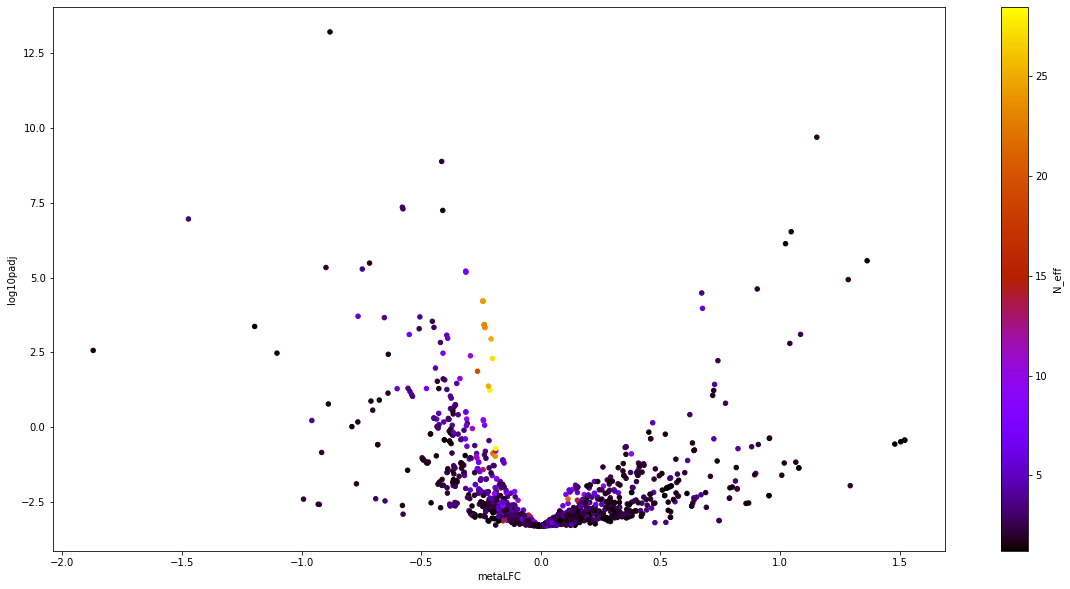

In [644]:
gene_ontology_results = GeneOntologyDifferentialResults.meta_estimates(deseq_results, balanced_matrix)
gene_ontology_results.query("top1_contribution < 0.9").plot.scatter(x="metaLFC", y="log10padj", c="N_eff", figsize=(20, 10), cmap="gnuplot")
gene_ontology_results.sort_values(by="padj").query("pval < 0.05 and n_terms > 1").query("top5_contribution < 0.95")

# Plotter

Given a go term, a balanced matrix, deseq results, and the global results, we would like to be able to plot a forest plot that displays:
- relative weight of a gene to the term
- estimates for that term
- global estimate

In [645]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class ForestPlotter:

    def __init__(self, deseq_results, balanced_matrix, gene_ontology_results):
        self.deseq_results = deseq_results
        self.balanced_matrix = balanced_matrix
        self.gene_ontology_results = gene_ontology_results

    def plot_term(
        self,
        term: str,
        cutoff=0.99,
        figsize=None,
        ci_multiplier=1.96,
        point_size=45,
        contribution_label=True,
        title=None,
    ):
        contributing_genes = self.balanced_matrix.index[
            self.balanced_matrix[term].gt(0)
        ]

        subset_df = self.deseq_results.loc[contributing_genes].copy()
        subset_weights = self.balanced_matrix.loc[contributing_genes, term]

        contribution = subset_weights / subset_weights.sum()
        meta_estimation = self.gene_ontology_results.loc[term]

        forest_df = pd.DataFrame({
            "gene": subset_df.index,
            "L2FC": subset_df["log2FoldChange"],
            "SE": subset_df["lfcSE"],
            "lower_ci": subset_df["log2FoldChange"] - ci_multiplier * subset_df["lfcSE"],
            "upper_ci": subset_df["log2FoldChange"] + ci_multiplier * subset_df["lfcSE"],
            "pct_contribution": contribution,
        })

        forest_df = forest_df.replace([np.inf, -np.inf], np.nan).dropna(
            subset=["L2FC", "SE", "pct_contribution"]
        )

        if cutoff is not None:
            keep_genes = (
                forest_df
                .sort_values("pct_contribution", ascending=False)
                .assign(cum_contribution=lambda df: df["pct_contribution"].cumsum())
                .loc[lambda df: df["cum_contribution"].le(cutoff), "gene"]
            )

            if len(keep_genes) == 0:
                keep_genes = (
                    forest_df
                    .sort_values("pct_contribution", ascending=False)
                    .head(1)["gene"]
                )

            forest_df = forest_df.loc[forest_df["gene"].isin(keep_genes)]

        forest_df = forest_df.sort_values("pct_contribution", ascending=True)

        n_genes = len(forest_df)

        if figsize is None:
            figsize = (11, max(5, 0.32 * n_genes + 2.5))

        fig, ax = plt.subplots(
            nrows=2,
            ncols=2,
            gridspec_kw={
                "width_ratios": [2.4, 1],
                "height_ratios": [max(4, n_genes * 0.3), 1],
                "hspace": 0.2,
                "wspace": 0.05,
            },
            figsize=figsize,
            sharex="col",
        )

        forest_ax = ax[0, 0]
        contrib_ax = ax[0, 1]
        meta_ax = ax[1, 0]
        empty_ax = ax[1, 1]

        y = np.arange(n_genes)

        colors = np.where(forest_df["L2FC"].ge(0), "firebrick", "steelblue")

        forest_ax.errorbar(
            x=forest_df["L2FC"],
            y=y,
            xerr=ci_multiplier * forest_df["SE"],
            fmt="none",
            ecolor="0.35",
            elinewidth=1.2,
            capsize=3,
            zorder=1,
        )

        forest_ax.scatter(
            x=forest_df["L2FC"],
            y=y,
            s=point_size,
            c=colors,
            edgecolor="black",
            linewidth=0.4,
            zorder=2,
        )

        forest_ax.axvline(0, color="black", linestyle=":", linewidth=1.2)
        forest_ax.set_yticks(y)
        forest_ax.set_yticklabels(forest_df["gene"])
        forest_ax.set_ylabel("")
        forest_ax.set_xlabel("log2 fold change")
        forest_ax.grid(axis="x", alpha=0.25)
        forest_ax.spines["top"].set_visible(False)
        forest_ax.spines["right"].set_visible(False)

        contrib_ax.barh(
            y=y,
            width=forest_df["pct_contribution"],
            color="0.45",
            edgecolor="black",
            linewidth=0.3,
        )

        contrib_ax.set_yticks(y)
        contrib_ax.set_yticklabels([])
        contrib_ax.set_xlabel("Contribution")
        contrib_ax.grid(axis="x", alpha=0.25)
        contrib_ax.spines["top"].set_visible(False)
        contrib_ax.spines["right"].set_visible(False)
        contrib_ax.spines["left"].set_visible(False)
        contrib_ax.tick_params(axis="y", length=0)

        if contribution_label:
            xmax = forest_df["pct_contribution"].max()
            for yi, value in zip(y, forest_df["pct_contribution"]):
                contrib_ax.text(
                    value + xmax * 0.02,
                    yi,
                    f"{value:.1%}",
                    va="center",
                    fontsize=8,
                )
            contrib_ax.set_xlim(0, xmax * 1.25)

        meta_lfc = meta_estimation["metaLFC"]
        meta_se = meta_estimation["metaSE"]

        meta_ax.errorbar(
            x=meta_lfc,
            y=[0],
            xerr=ci_multiplier * meta_se,
            fmt="none",
            ecolor="0.35",
            elinewidth=1.4,
            capsize=4,
            zorder=1,
        )

        meta_color = "firebrick" if meta_lfc >= 0 else "steelblue"

        meta_ax.scatter(
            x=[meta_lfc],
            y=[0],
            s=70,
            c=meta_color,
            edgecolor="black",
            linewidth=0.5,
            zorder=2,
        )

        meta_ax.axvline(0, color="black", linestyle=":", linewidth=1.2)
        meta_ax.set_yticks([0])
        meta_ax.set_yticklabels(["Meta-estimate"])
        meta_ax.set_xlabel("meta log2 fold change")
        meta_ax.grid(axis="x", alpha=0.25)
        meta_ax.spines["top"].set_visible(False)
        meta_ax.spines["right"].set_visible(False)

        empty_ax.axis("off")

        if title is None:
            title = term

        fig.suptitle(
            title,
            fontsize=13,
            fontweight="bold",
            y=0.98,
        )

        displayed_contribution = forest_df["pct_contribution"].sum()

        fig.text(
            0.01,
            0.01,
            f"Displayed genes: {n_genes} | Displayed contribution: {displayed_contribution:.1%}",
            fontsize=9,
            color="0.35",
        )

        plt.tight_layout(rect=[0, 0.03, 1, 0.96])

        return forest_df, fig, ax

In [648]:
gene_ontology_results.query("padj < 0.05 and top5_contribution < 0.9").sort_values(by='padj')

,n_terms,metaLFC,metaSE,lower_ci,upper_ci,weight,pval,padj,log10p,log10padj,top1_contribution,top5_contribution,N_eff
SUMOylation,158,-0.314076,0.052923,-0.417806,-0.210346,5.068904,2.946456e-09,0.000006,8.530700,5.218311,0.224497,0.758812,6.995951
SUMO E3 Ligases SUMOylate Target Proteins,153,-0.313356,0.052929,-0.417097,-0.209615,5.036953,3.213509e-09,0.000007,8.493021,5.180632,0.225688,0.762838,6.923066
Regulation of MITF-M-dependent Genes Involved in Lysosome Biogenesis and Autophagy,15,0.672595,0.119003,0.439349,0.905842,2.772589,1.586719e-08,0.000033,7.799500,4.487111,0.459576,0.887037,3.390889
Major Pathway of rRNA Processing in the Nucleolus and Cytosol,171,-0.242392,0.043726,-0.328095,-0.156689,5.147494,2.965887e-08,0.000061,7.527845,4.215456,0.098792,0.337163,24.339921
rRNA Processing in the Nucleus and Cytosol,180,-0.242385,0.043726,-0.328087,-0.156682,5.198497,2.968757e-08,0.000061,7.527425,4.215036,0.098776,0.337106,24.348028
rRNA Processing,189,-0.242383,0.043726,-0.328086,-0.156680,5.247024,2.969282e-08,0.000061,7.527349,4.214960,0.098767,0.337077,24.352219
Metabolism of Lipids,491,0.675844,0.124132,0.432545,0.919143,6.198479,5.193671e-08,0.000107,7.284526,3.972137,0.352916,0.739999,5.621589
Activation of the Pre-Replicative Complex,30,-0.764398,0.143273,-1.045213,-0.483582,3.433987,9.541282e-08,0.000196,7.020393,3.708004,0.290940,0.851340,5.176513
Selenocysteine Synthesis,88,-0.236697,0.045365,-0.325612,-0.147782,4.488636,1.812224e-07,0.000372,6.741788,3.429399,0.103386,0.352842,23.184667
Viral mRNA Translation,85,-0.236582,0.045365,-0.325498,-0.147666,4.454347,1.837621e-07,0.000377,6.735744,3.423355,0.103380,0.352820,23.187767


/var/folders/2n/j06nrn2n7r524t776sngh0xr0000gr/T/ipykernel_38808/170531005.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


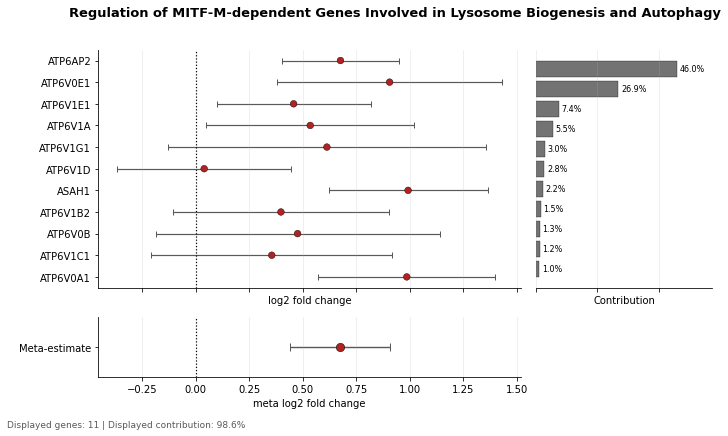

In [650]:
term = "Regulation of MITF-M-dependent Genes Involved in Lysosome Biogenesis and Autophagy"

output = ForestPlotter(deseq_results, balanced_matrix, gene_ontology_results).plot_term(term, cutoff=0.99)